# 🌾 Predicting Agricultural Irrigation Needs
Welcome to this notebook! In modern agriculture, efficient water management is everything. Knowing exactly how much irrigation a crop needs can drastically improve yield, reduce costs, and conserve vital resources. 

In this project, we will:
1. Explore environmental factors, soil metrics, and weather patterns.
2. Preprocess categorical features to find the strongest predictive signals for crop health.
3. Train **LightGBM** and **XGBoost** models to evaluate the terrain and accurately classify the `Irrigation_Need` (Low, Medium, or High).

## 1. Imports & Setup

The notebook uses a rich set of libraries: **Pandas** for data manipulation, **Seaborn/Matplotlib** for visualization, **Scikit-learn** for modeling utilities, and **XGBoost/LightGBM** as the core gradient boosting models.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

Two CSV files are loaded — `train.csv` (with labels) and `test.csv` (without labels). Basic exploration is done via `.head()`, `.info()`, and `.isnull().sum()` to understand the structure, data types, and missing values.

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [ ]:
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [ ]:
train.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [ ]:
train.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis (EDA)

Two sets of visualizations are created:

- **Categorical features** (e.g., Soil Type, Crop Type, Season, Region) are plotted as count plots grouped by the target class `Irrigation_Need`, revealing how each category distributes across irrigation levels.
- **Numerical features** (e.g., Temperature, Humidity, Rainfall) are plotted as histograms with KDE curves, again split by the target, to observe how their distributions differ across irrigation classes.

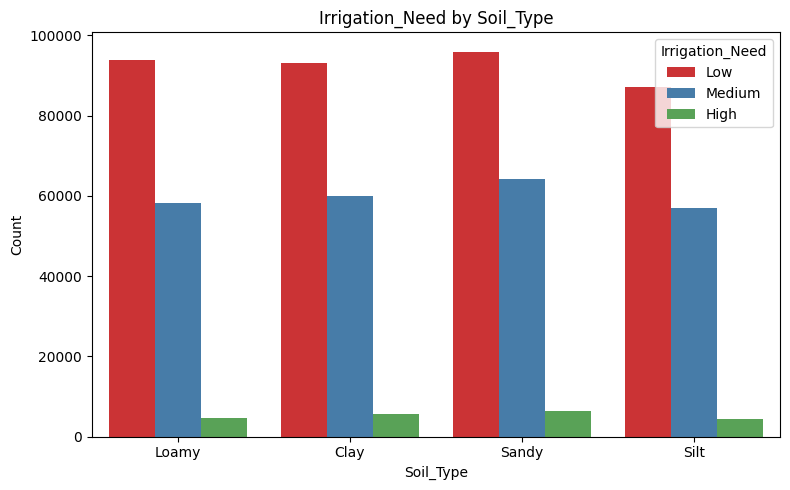

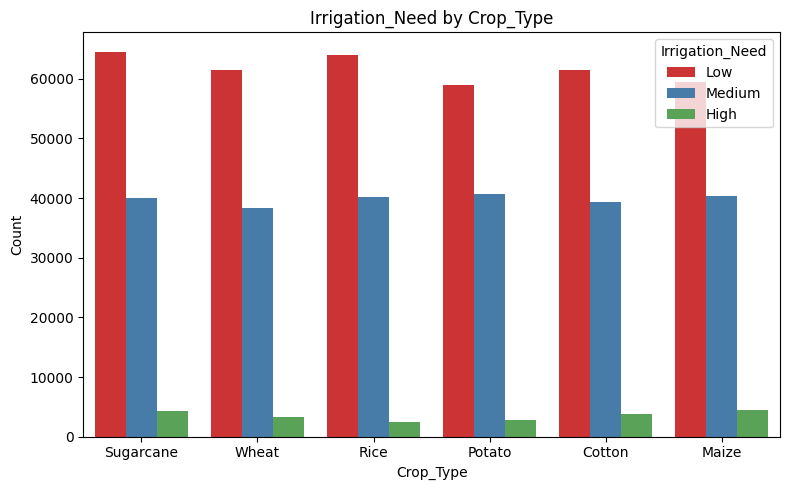

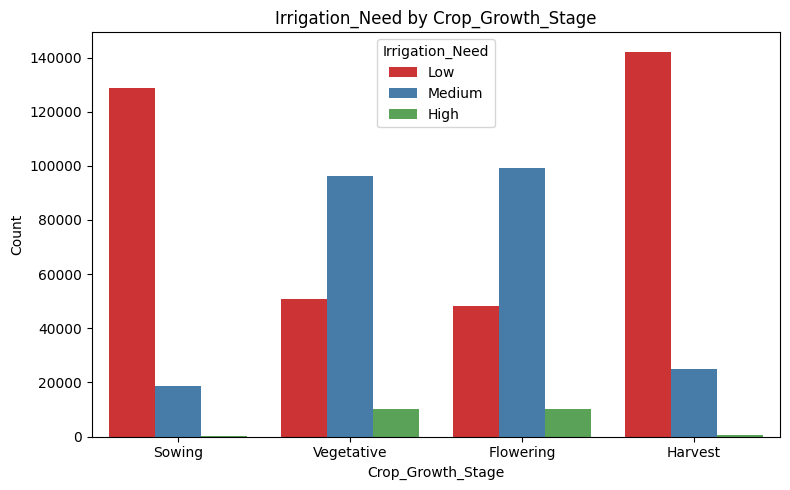

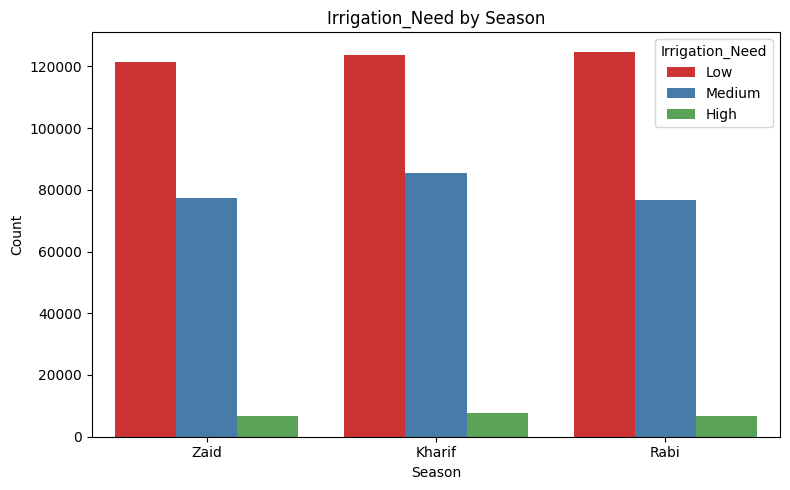

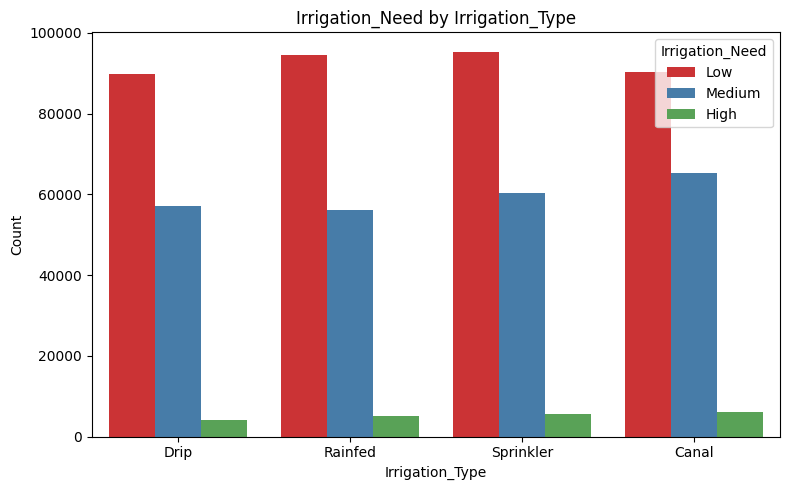

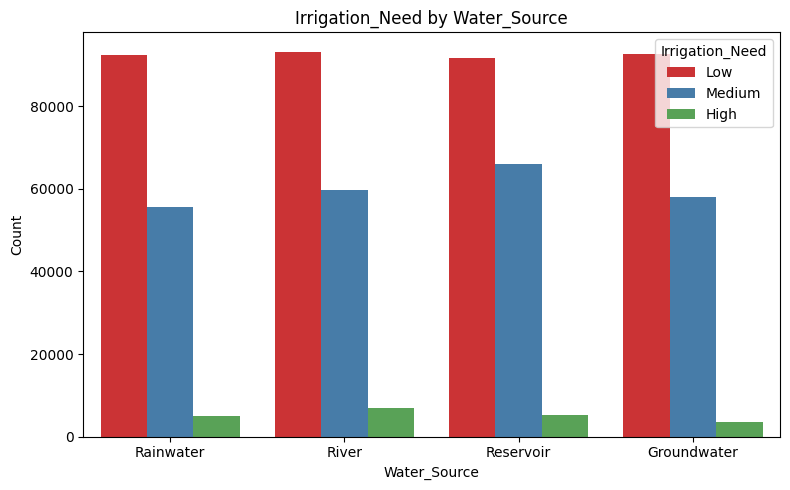

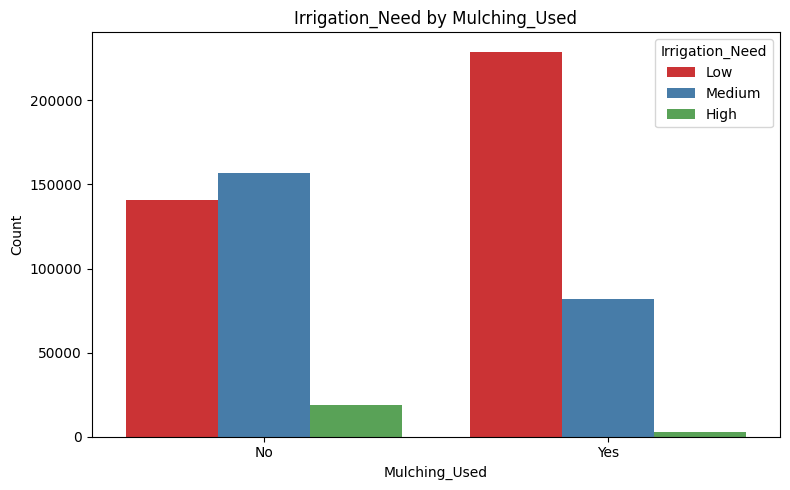

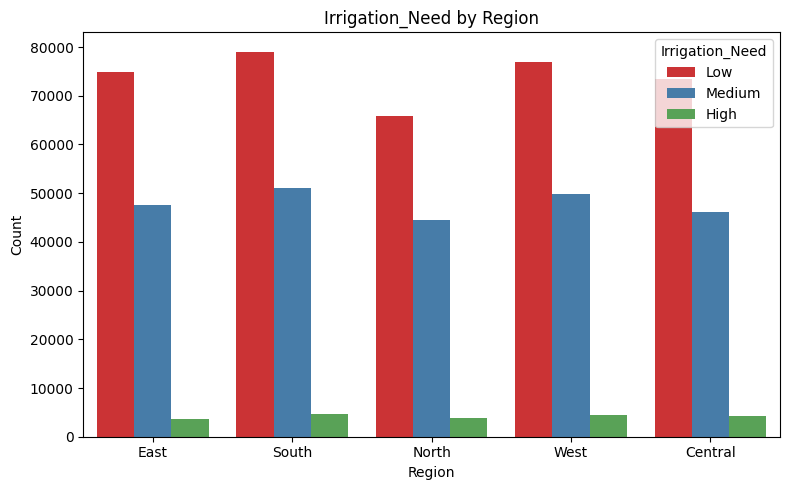

In [ ]:
# Categorical Features Visualizations
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='Irrigation_Need', data=train, palette='Set1')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Irrigation_Need by {col}')
    plt.tight_layout()
    plt.show()

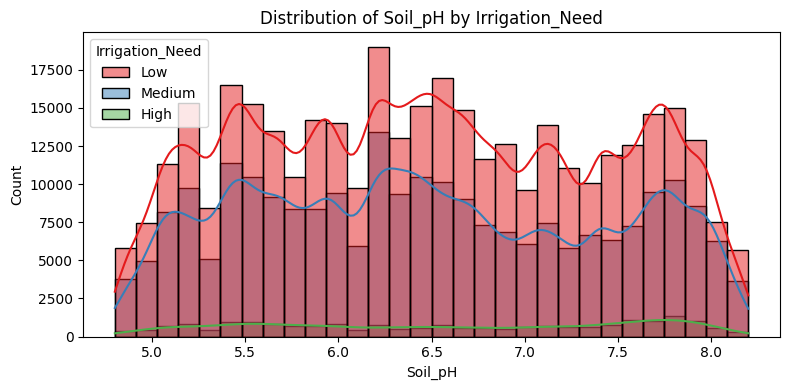

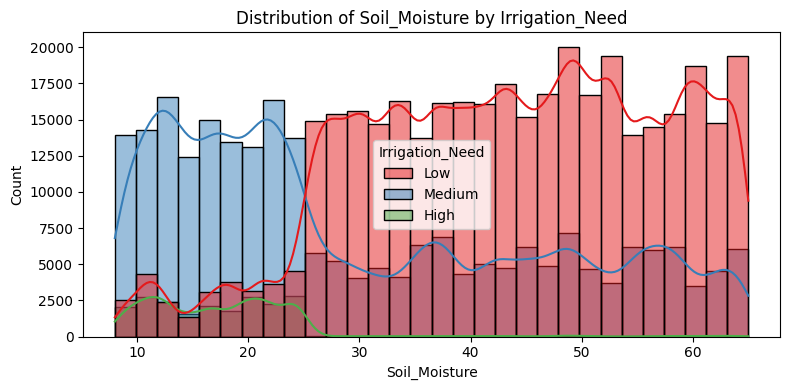

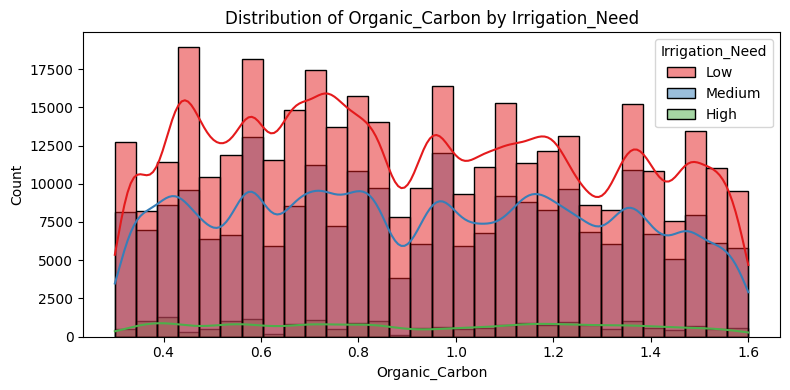

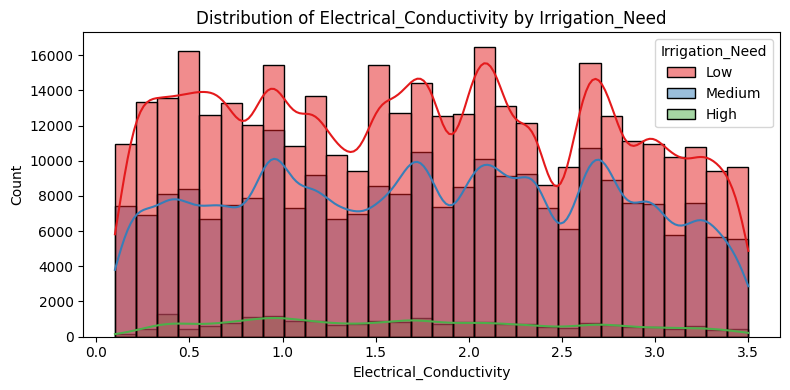

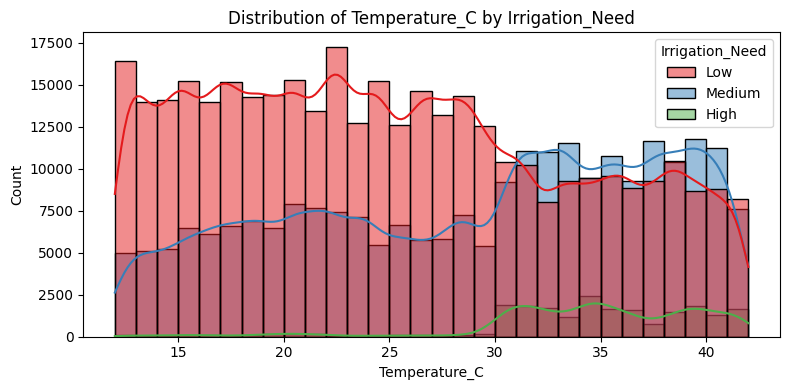

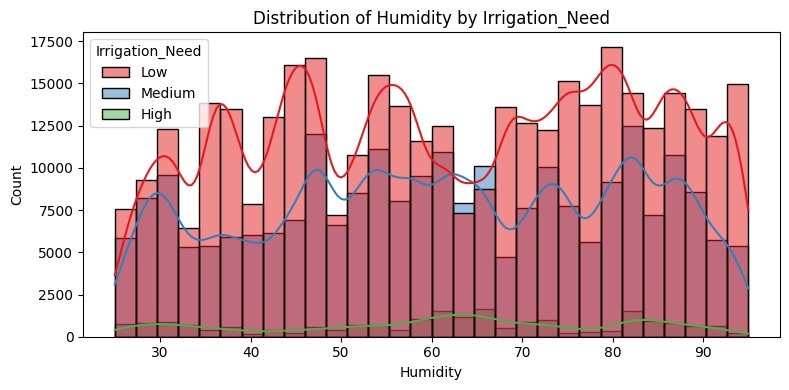

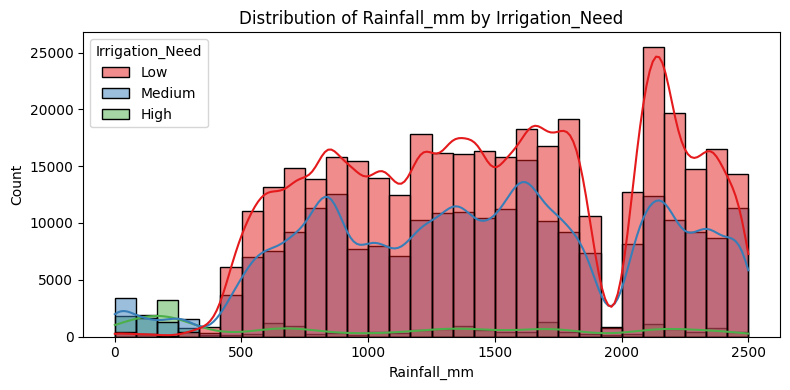

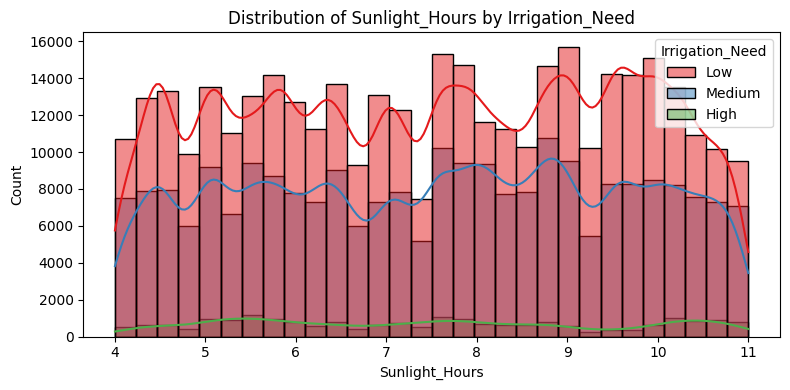

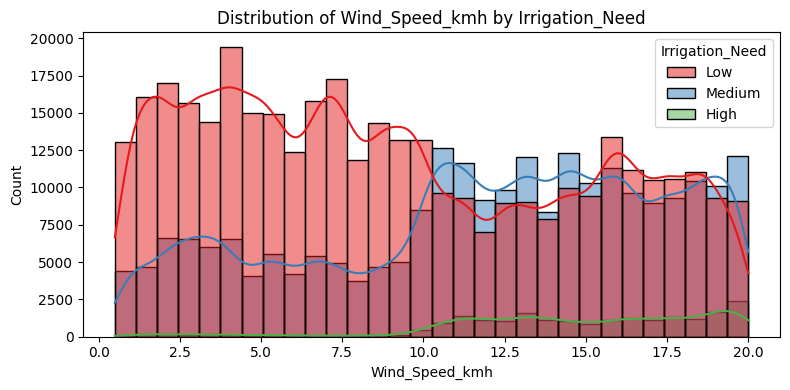

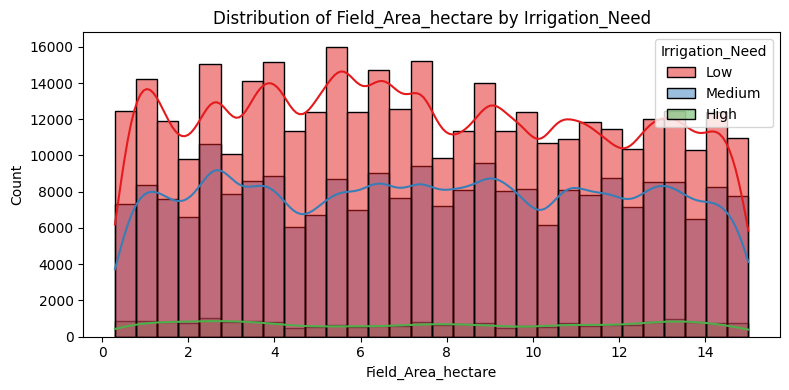

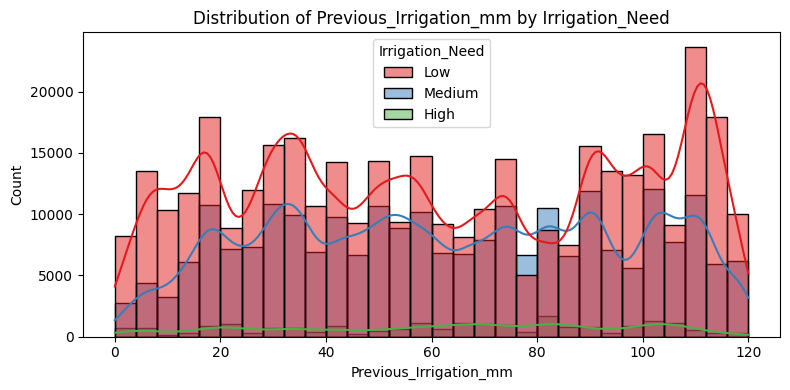

In [ ]:
# Numerical Features Visualizations
num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 
            'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=col, hue='Irrigation_Need', data=train, bins=30, kde=True, palette='Set1')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col} by Irrigation_Need')
    plt.tight_layout()
    plt.show()

## 4. Feature Engineering

This is the most impactful section. New features are derived from the existing ones to help the model learn patterns more effectively:

- **Interaction features** — multiply two related columns together (e.g., `Soil_Moisture × Rainfall_mm`) to capture joint effects.
- **Ratio features** — divide one column by another (e.g., `Humidity / Temperature`) to capture relative relationships.
- **Aggregate proxy features** — `Water_Availability` sums moisture, rainfall, and previous irrigation to create a single water supply indicator. `Evap_Stress` estimates evaporation pressure using temperature, wind, and humidity.
- **Group aggregation features** — for each row, the deviation from the group mean is computed (e.g., how a field's soil moisture compares to the average for its crop type). This adds contextual, relative information.

The same transformations are applied to both `train` and `test` to ensure consistency.

In [ ]:
def feature_engineering(df):
    df = df.copy()

    # Interaction features
    df['Moisture_x_Rainfall']     = df['Soil_Moisture'] * df['Rainfall_mm']
    df['Temp_x_Humidity']         = df['Temperature_C'] * df['Humidity']
    df['Sunlight_x_Wind']         = df['Sunlight_Hours'] * df['Wind_Speed_kmh']
    df['EC_x_pH']                 = df['Electrical_Conductivity'] * df['Soil_pH']
    df['Area_x_PrevIrrigation']   = df['Field_Area_hectare'] * df['Previous_Irrigation_mm']

    # Ratio features
    df['Moisture_Rain_Ratio']     = df['Soil_Moisture'] / (df['Rainfall_mm'] + 1)
    df['Humidity_Temp_Ratio']     = df['Humidity'] / (df['Temperature_C'] + 1)

    # Aggregate: total water availability proxy
    df['Water_Availability']      = df['Soil_Moisture'] + df['Rainfall_mm'] + df['Previous_Irrigation_mm']

    # Evaporation stress proxy
    df['Evap_Stress']             = df['Temperature_C'] * df['Wind_Speed_kmh'] / (df['Humidity'] + 1)

    # Group Aggregations: Comparing numericals against Categorical groups
    # Average moisture for the specific Crop_Type
    crop_moisture_mean = df.groupby('Crop_Type')['Soil_Moisture'].transform('mean')
    df['Moisture_vs_Crop_Mean'] = df['Soil_Moisture'] - crop_moisture_mean
    
    # Average temperature for the Region
    region_temp_mean = df.groupby('Region')['Temperature_C'].transform('mean')
    df['Temp_vs_Region_Mean'] = df['Temperature_C'] - region_temp_mean
    
    # Average rainfall for the Season
    season_rain_mean = df.groupby('Season')['Rainfall_mm'].transform('mean')
    df['Rain_vs_Season_Mean'] = df['Rainfall_mm'] - season_rain_mean

    return df


train = feature_engineering(train)
test  = feature_engineering(test)

## 5. Encoding

- The **target variable** (`Irrigation_Need`) is label-encoded: `Low → 0`, `Medium → 1`, `High → 2`.
- All **categorical feature columns** are label-encoded using `LabelEncoder`, fitted on the combined train+test data to handle all possible categories safely.


In [ ]:
# Map target variable
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
inv_label_map = {v: k for k, v in label_map.items()}

train['Irrigation_Need'] = train['Irrigation_Need'].map(label_map)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    encoders[col] = le

In [ ]:
drop_cols = ['id', 'Irrigation_Need']
feature_cols = [col for col in train.columns if col not in drop_cols]

X = train[feature_cols]
y = train['Irrigation_Need']
X_test = test[feature_cols]

print(f"Features used: {len(feature_cols)}")
print(feature_cols)

Features used: 31
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Moisture_x_Rainfall', 'Temp_x_Humidity', 'Sunlight_x_Wind', 'EC_x_pH', 'Area_x_PrevIrrigation', 'Moisture_Rain_Ratio', 'Humidity_Temp_Ratio', 'Water_Availability', 'Evap_Stress', 'Moisture_vs_Crop_Mean', 'Temp_vs_Region_Mean', 'Rain_vs_Season_Mean']


## 6. Model Building — Stacking Ensemble

Three base models are defined:

| Model | Role |
|---|---|
| **XGBoost** | Gradient boosting, handles complex patterns |
| **LightGBM** | Faster gradient boosting, good on large data |
| **Random Forest** | Bagging-based, adds diversity |

These three are combined in a **StackingClassifier**, where their predictions become inputs to a **Logistic Regression meta-learner**. Stacking helps because each model captures different aspects of the data, and the meta-learner learns the optimal way to combine them.


In [ ]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

In [ ]:
stacking = StackingClassifier(
    estimators=[
        ('xgb',  xgb),
        ('lgbm', lgbm),
        ('rf',   rf),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

## 7. Cross-Validation

**5-fold Stratified Cross-Validation** is used to evaluate the stacking model before training on the full dataset. Stratified folds ensure each fold has a proportional representation of all three target classes — critical for imbalanced datasets.

In [ ]:
print("Running 5-fold cross-validation on stacking ensemble...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(stacking, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold:    {cv_scores}")

Running 5-fold cross-validation on stacking ensemble...

CV Accuracy: 0.9851 ± 0.0002
Per-fold:    [0.98522222 0.98503968 0.98476984 0.98519048 0.9852381 ]


## 8. Final Training & Submission

The stacking model is trained on the **entire training set**, predictions are made on the test set, and the numeric predictions are decoded back to their original labels (`0 → Low`, etc.). The final output is saved as `submission.csv`.

In [ ]:
print("\nTraining final model on full training data...")
stacking.fit(X, y)

y_pred_encoded = stacking.predict(X_test)
y_pred_labels  = [inv_label_map[p] for p in y_pred_encoded]


Training final model on full training data...


In [ ]:
submission = pd.DataFrame({
    'id':             test['id'],
    'Irrigation_Need': y_pred_labels,
})

submission.to_csv('submission.csv', index=False)
print("\nsubmission.csv saved!")
print(submission['Irrigation_Need'].value_counts())
print(submission.head(10))


submission.csv saved!
Irrigation_Need
Low       159732
Medium    101624
High        8644
Name: count, dtype: int64
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low


## 9. Feature Importance

A standalone **XGBoost model** is trained solely to extract and visualize feature importances. The top 20 most influential features are plotted as a horizontal bar chart, giving insight into which variables drive the model's decisions the most.

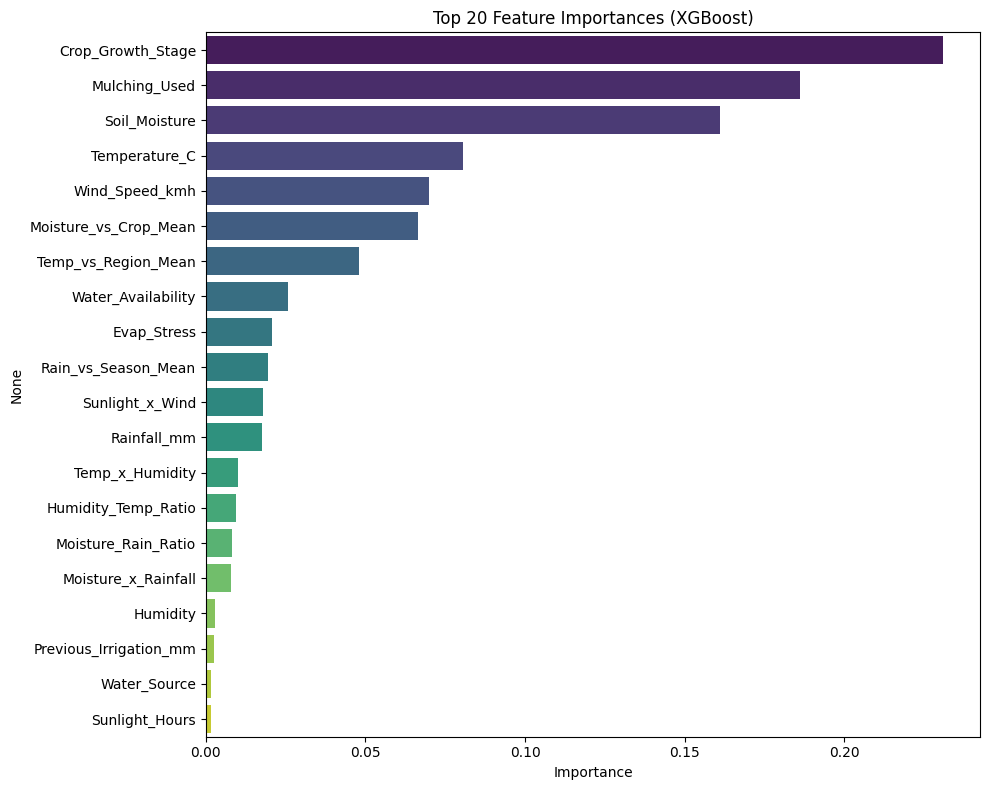


Top 10 features:
 Crop_Growth_Stage        0.231005
Mulching_Used            0.186114
Soil_Moisture            0.161195
Temperature_C            0.080578
Wind_Speed_kmh           0.069986
Moisture_vs_Crop_Mean    0.066378
Temp_vs_Region_Mean      0.047983
Water_Availability       0.025864
Evap_Stress              0.020700
Rain_vs_Season_Mean      0.019366
dtype: float32


In [ ]:
xgb_solo = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1,
)
xgb_solo.fit(X, y)

importances = pd.Series(xgb_solo.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values[:20], y=importances.index[:20], palette='viridis')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print("\nTop 10 features:\n", importances.head(10))